# Experiment 2 — vertical advective heating summary

The quantity is the vertical advective heating **w · ∂T/∂z** (°C/day). Two averages:
**[ · ]** is a spatial average over the array footprint (the array estimate, or the
model truth averaged over the same footprint); **⟨ · ⟩** is a time average.

Two sets of figures, each with an **equator** shape sweep and an off-equator **shift**
(diamond / hexagon / square) variant:

1. **Area-average** — the footprint-mean heating.
   - *components* (structural): the truth splits as ⟨[w·∂T/∂z]⟩ (true total) = est mean
     ⟨[w][∂T/∂z]⟩_est + **estimate error** (true mean − est mean, observable) + **subgrid**
     ⟨[w·∂T/∂z]⟩ − ⟨[w][∂T/∂z]⟩_true (within-footprint covariance, unobservable).
   - *reducible*: the plane-fit / sampling errors — ⟨[w]⟩, ⟨[∂T/∂z]⟩, and the heating each
     as true vs estimate and the estimate error (true − estimate).
2. **Point** — the array's single area-mean w used as a stand-in for the local w at
   each glider, applied to that glider's own ∂T/∂z. Truth vs estimate, truth − estimate,
   then the error split into a w-substitution part and a gradient (2 m vs native) part.
3. **Shift summary** — the depth-mean of each error term vs latitude, per shape.
4. **Context maps** — where in the box the footprint average is least reliable.

Shape colours are consistent with the equator experiments: diamond = blue, hexagon =
green, square = red. The shift figures share x-limits across latitude for comparison.

In [1]:
import os, sys
import matplotlib.pyplot as plt

REPO = "/home/edavenport/analysis/tpose24-osse"
HERE = os.path.join(REPO, "experiments", "experiment_2")
sys.path.insert(0, REPO)
import heat_flux_fig_tools as hft

DATA = os.path.join(HERE, "data_heat")
HFIGDIR = os.path.join(HERE, "heat_flux_figs"); os.makedirs(HFIGDIR, exist_ok=True)
plt.rcParams["figure.dpi"] = 120
hft.apply_style()

def save(fig, name):
    fig.savefig(os.path.join(HFIGDIR, name), bbox_inches="tight", dpi=150)
    return fig

## Area-average — flux components (structural)

Three rows separating the *observable* estimate error from the *unobservable* subgrid,
using `[·]` = footprint spatial average, `⟨·⟩` = time average:
1. **true mean** ⟨[w][∂T/∂z]⟩_true (solid) vs **estimated mean** ⟨[w][∂T/∂z]⟩_est (dashed);
2. **estimate error** = true mean − est mean;
3. **subgrid (unobservable)** = true total − true mean = ⟨[w·∂T/∂z]⟩ − ⟨[w][∂T/∂z]⟩_true,
   the within-footprint covariance no single footprint value can see.

Identity: true total = est mean + estimate error + subgrid. Equator (**a**) is split into
1° and 2° cell-height figures (3 shapes each, columns = diameter); shift (**b**) columns =
centre latitude (−1.5 … +1.5°).

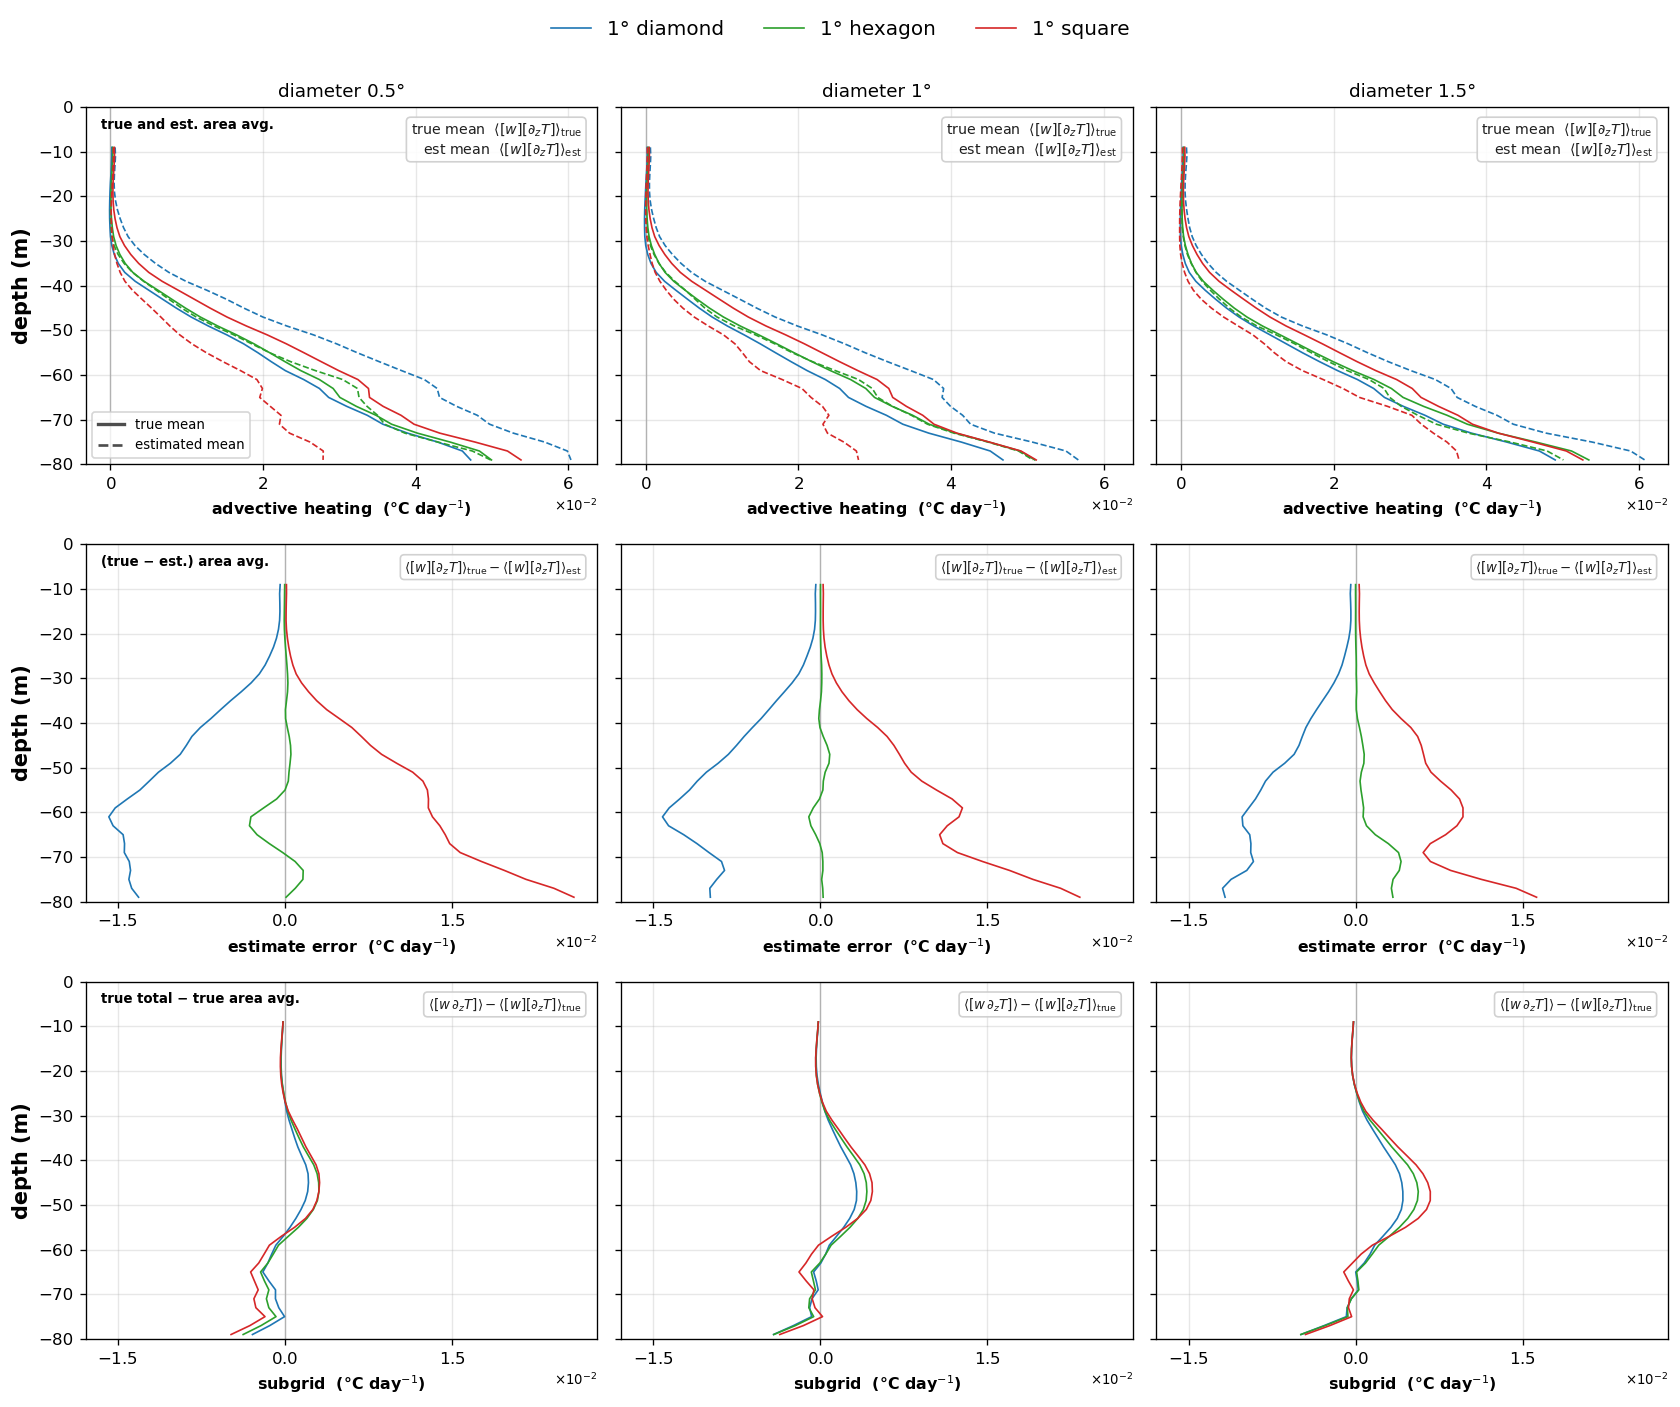

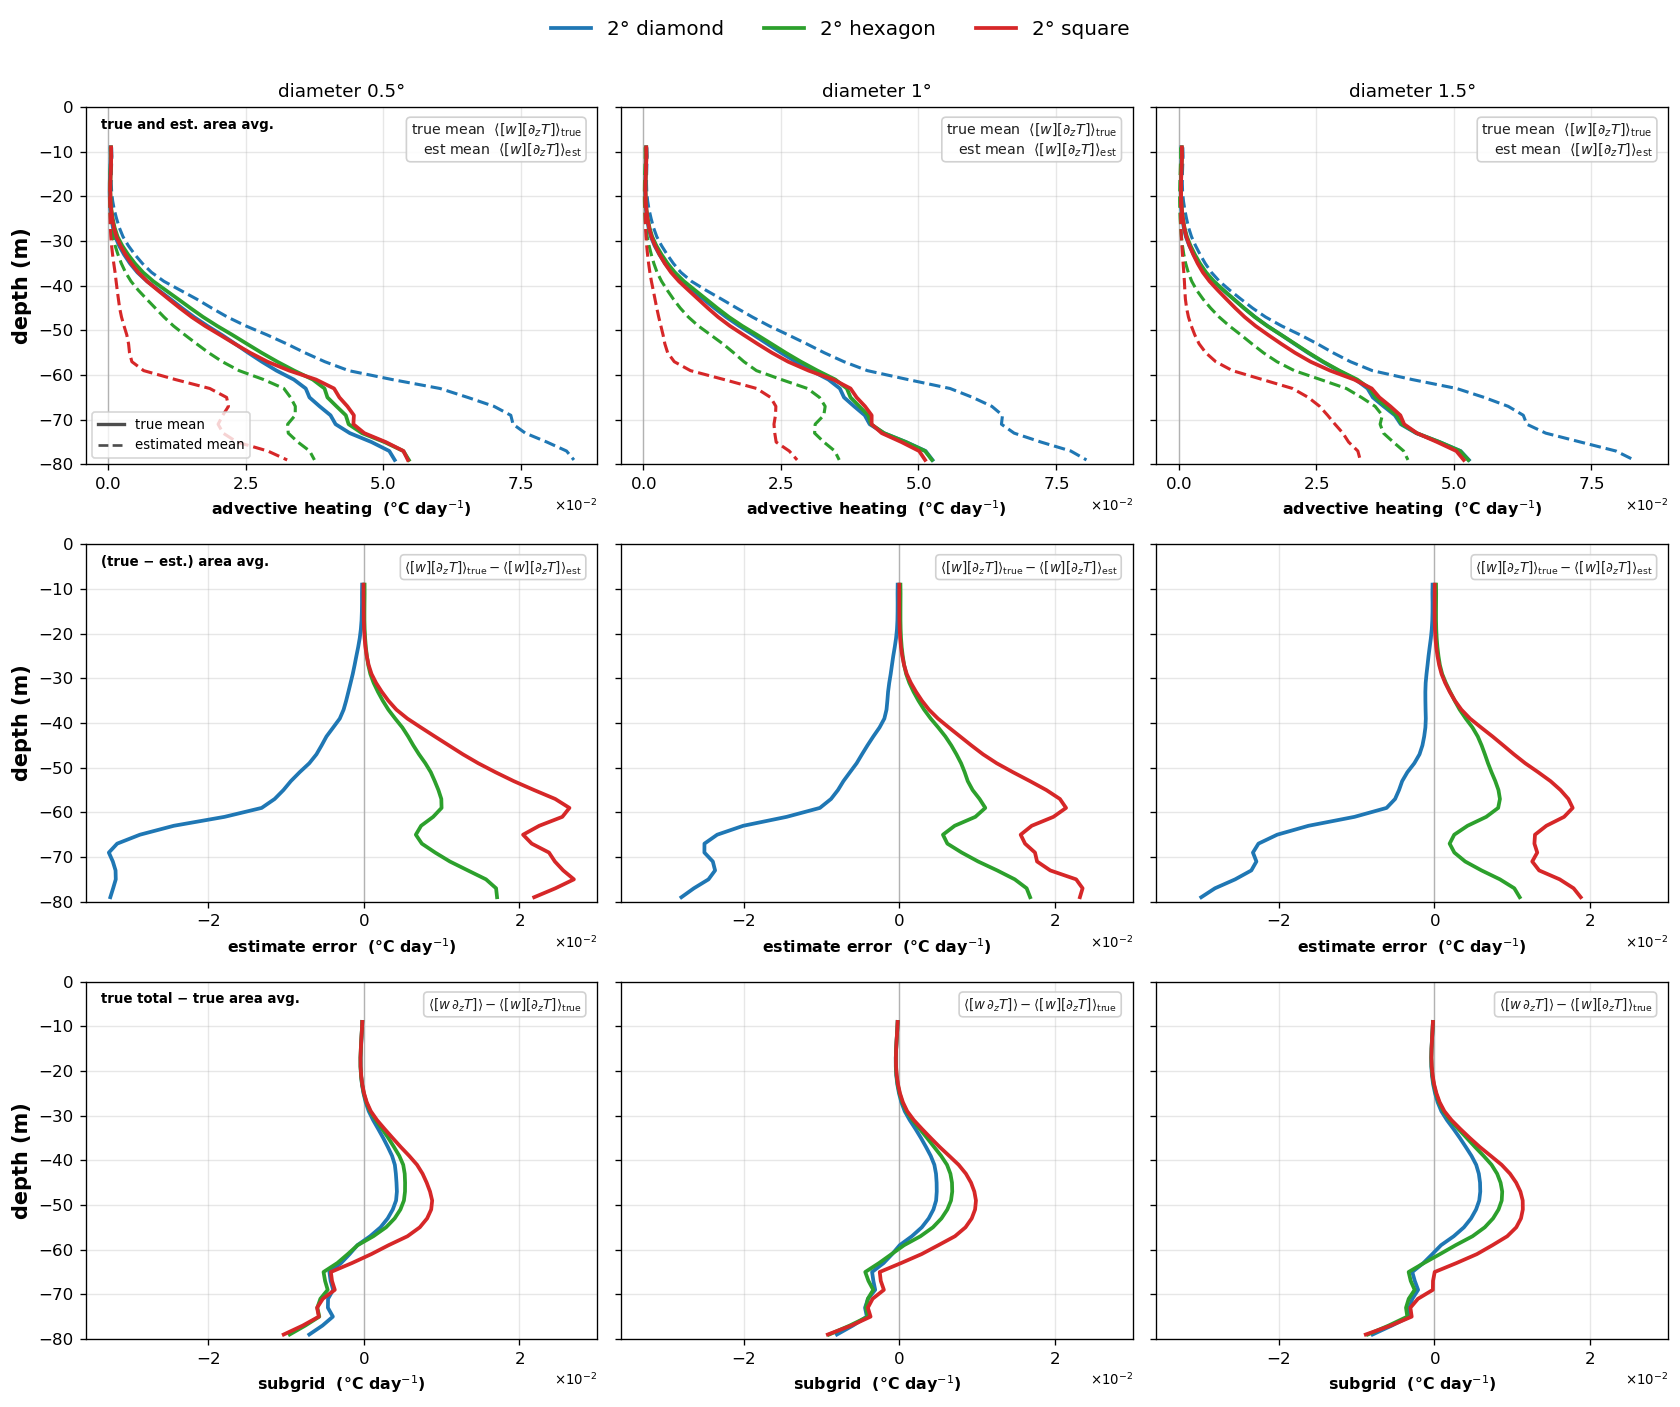

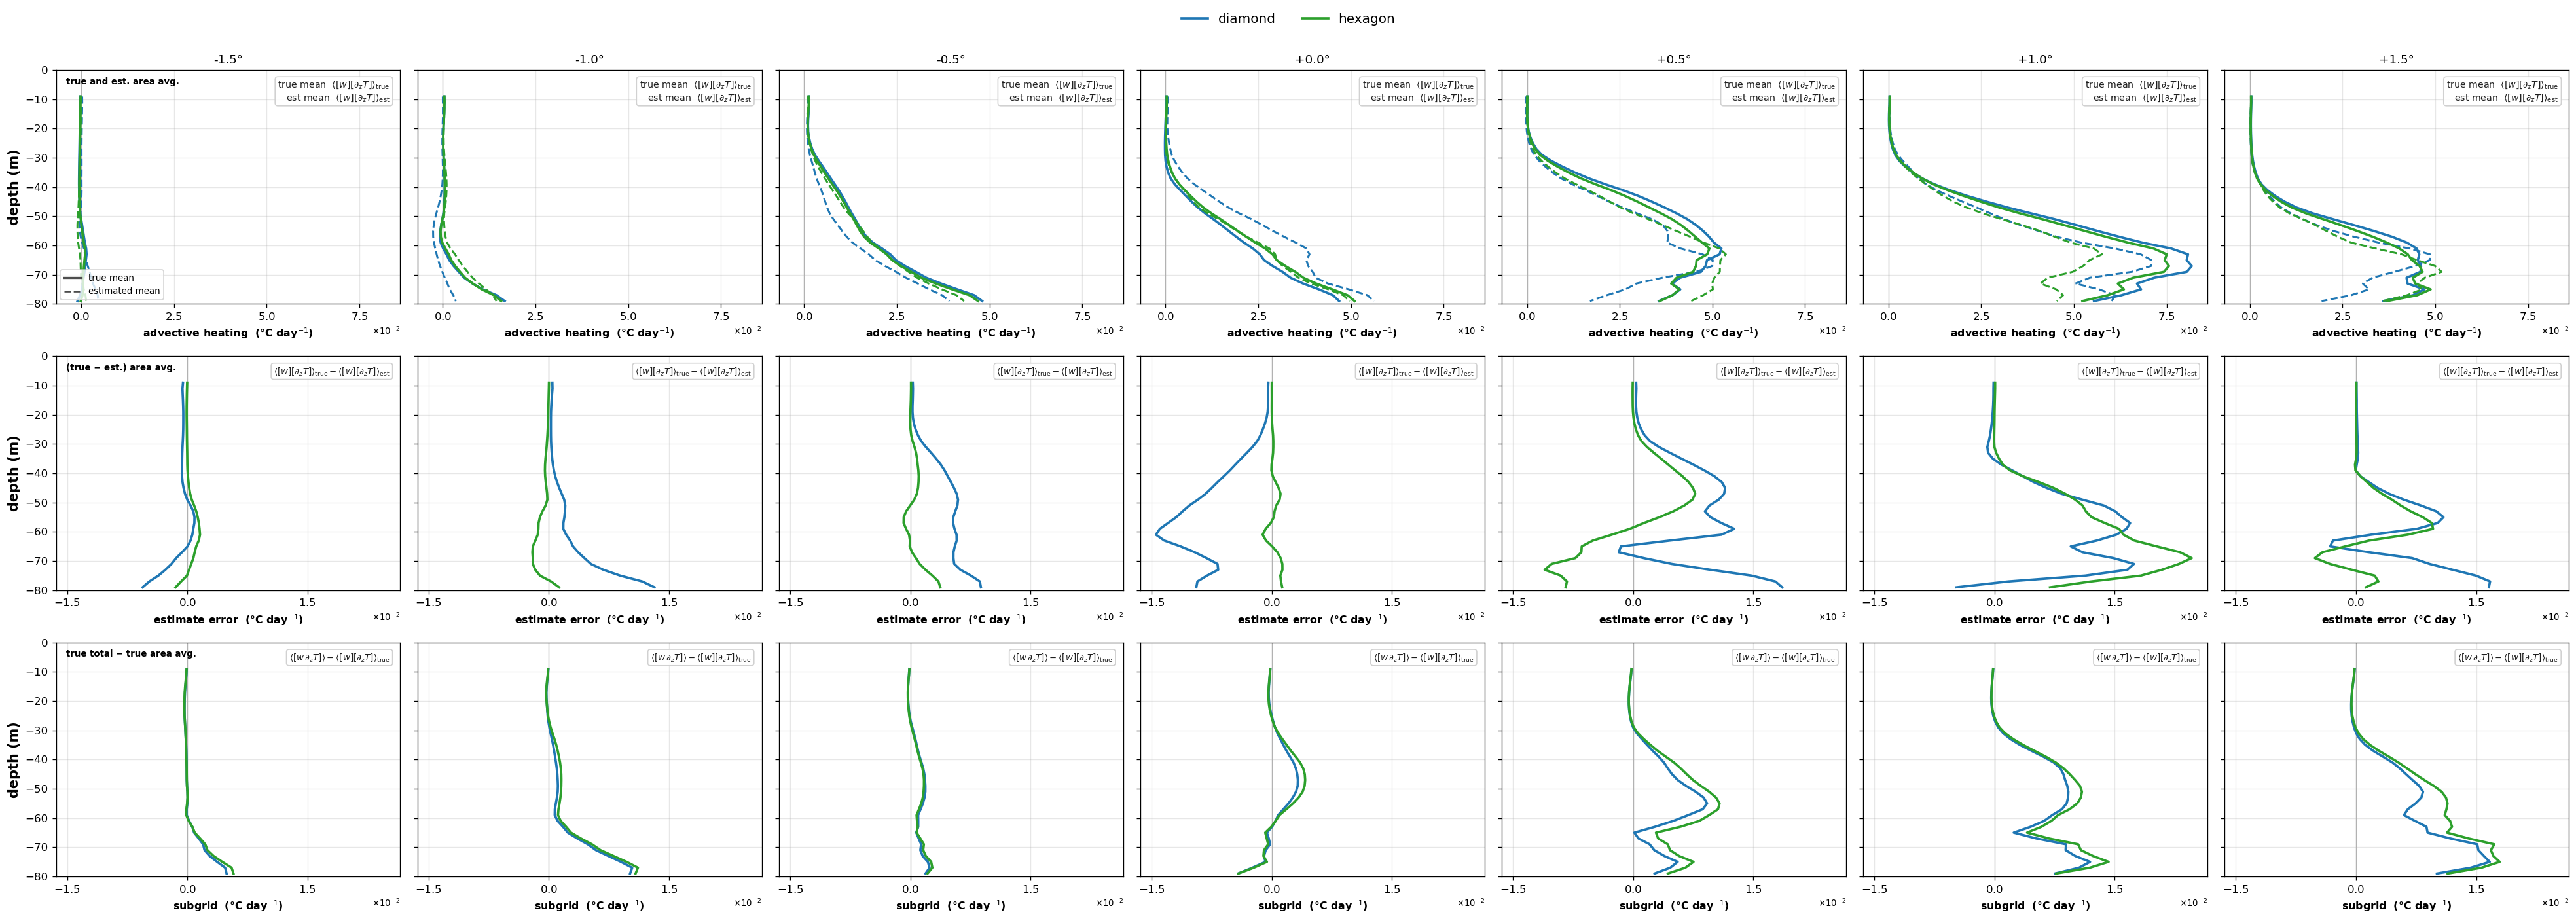

In [2]:
save(hft.make_area_components_a(DATA, hft.EQ_SHAPES_1DEG), "area_components_equator_1deg.png");
save(hft.make_area_components_a(DATA, hft.EQ_SHAPES_2DEG), "area_components_equator_2deg.png");
save(hft.make_area_components_b(DATA), "area_components_shift.png");

## Area-average — reducible (plane-fit / sampling) errors

Rows: ⟨[w]⟩, ⟨[∂T/∂z]⟩, and the advective heating ⟨[w][∂T/∂z]⟩. Left column = true (solid)
vs estimate (dashed); right column = **estimate error** (true − estimate). [w]_est is the
plane fit at the moorings, [∂T/∂z]_est the glider-average gradient, and the bottom-right
panel is the heating estimate error ⟨[w][∂T/∂z]⟩_true − ⟨[w][∂T/∂z]⟩_est — identical to the
estimate-error row of the components figure. **a** = equator shapes, split into 1° and 2°
cell-height figures (diameter 1°); **b** = shift diamond / hexagon / square, one figure per
centre latitude (0°, +0.5°, +1.5°; latitude in the column titles), sharing x-limits across
latitude for comparison.

In [ ]:
save(hft.make_area_reducible_a(DATA, hft.EQ_SHAPES_1DEG), "area_reducible_equator_1deg.png");
save(hft.make_area_reducible_a(DATA, hft.EQ_SHAPES_2DEG), "area_reducible_equator_2deg.png");
rx = hft.shift_reducible_xlims(DATA)   # shared x-limits across the shift latitudes
for lat in hft.B_REP_LATS:
    save(hft.make_area_reducible_b(DATA, lat, rx), f"area_reducible_shift_{lat:+.1f}deg.png");

## Point — area-mean w as a stand-in at each glider

The array's single area-mean w [w] applied to each glider's **own local** ∂T/∂z, then
averaged over the gliders. Notation for this set: `⟨·⟩` averages over time **and** the
gliders (one profile), and `[·]` is the plane-fit footprint average — it appears **only**
on the stand-in w. Local per-glider w and ∂T/∂z stay bare, so the truth carries no `[·]`.
Four columns: (1) truth `⟨w·∂T/∂z⟩` vs estimate `⟨[w]·∂T/∂z⟩`; (2) **truth − estimate**
(total point error); (3) the w-substitution error; (4) the gradient error (2 m glider
sampling vs model native). w-substitution + gradient = the exact point error; columns 3–4
share x-limits so their magnitudes compare directly (w-substitution dominates; gradient is
small). **a** = equator shapes (1°/2° figures); **b** = shift diamond / hexagon / square,
one figure per centre latitude (0°, +0.5°, +1.5°), sharing x-limits across latitude.

`point_flux_shift_+0.0deg_mooring.png` is the same as `point_flux_shift_+0.0deg` but the
single "glider" is **just the 0°N, 140°W TAO mooring** at the cell centre (no glider
averaging): each shape's area-mean `[w]` against the local flux at the mooring. The truth
is identical for all shapes; only the `[w]` estimate differs.

In [ ]:
save(hft.make_point_flux_a(DATA, hft.EQ_SHAPES_1DEG), "point_flux_equator_1deg.png");
save(hft.make_point_flux_a(DATA, hft.EQ_SHAPES_2DEG), "point_flux_equator_2deg.png");
px = hft.shift_point_xlims(DATA)   # shared x-limits across the shift latitudes
for lat in hft.B_REP_LATS:
    save(hft.make_point_flux_b(DATA, lat, px), f"point_flux_shift_{lat:+.1f}deg.png");
# same as point_flux_shift_+0.0deg but using ONLY the 0°N,140°W mooring (cell centre)
save(hft.make_point_flux_mooring(DATA), "point_flux_shift_+0.0deg_mooring.png");

## Shift summary — error scaling with latitude

The 0–80 m depth-mean of each advective-heating error term (°C/day) vs centre latitude,
one line per shape (diamond/hexagon/square). Area terms (**estimate error**, **subgrid**)
come from the cell datasets; point terms (**w-substitution**, **gradient**) from the glider
companions. A one-figure summary of how the shift experiments' errors grow/flip off the
equator.

In [ ]:
save(hft.make_error_scaling_shift(DATA), "error_scaling_shift.png");

## Context maps — where the footprint average is least reliable

Mean w, mean advective heating, and the temporal variability of w and of ∂T/∂z over
the equatorial box at 25/50/75 m and a 0–80 m depth average, with a representative 1°
footprint (black). The footprint average loses the most where these vary strongly
across the footprint. Needs `run_subcell_diag.py` (→ cache/subcell_maps.pkl).

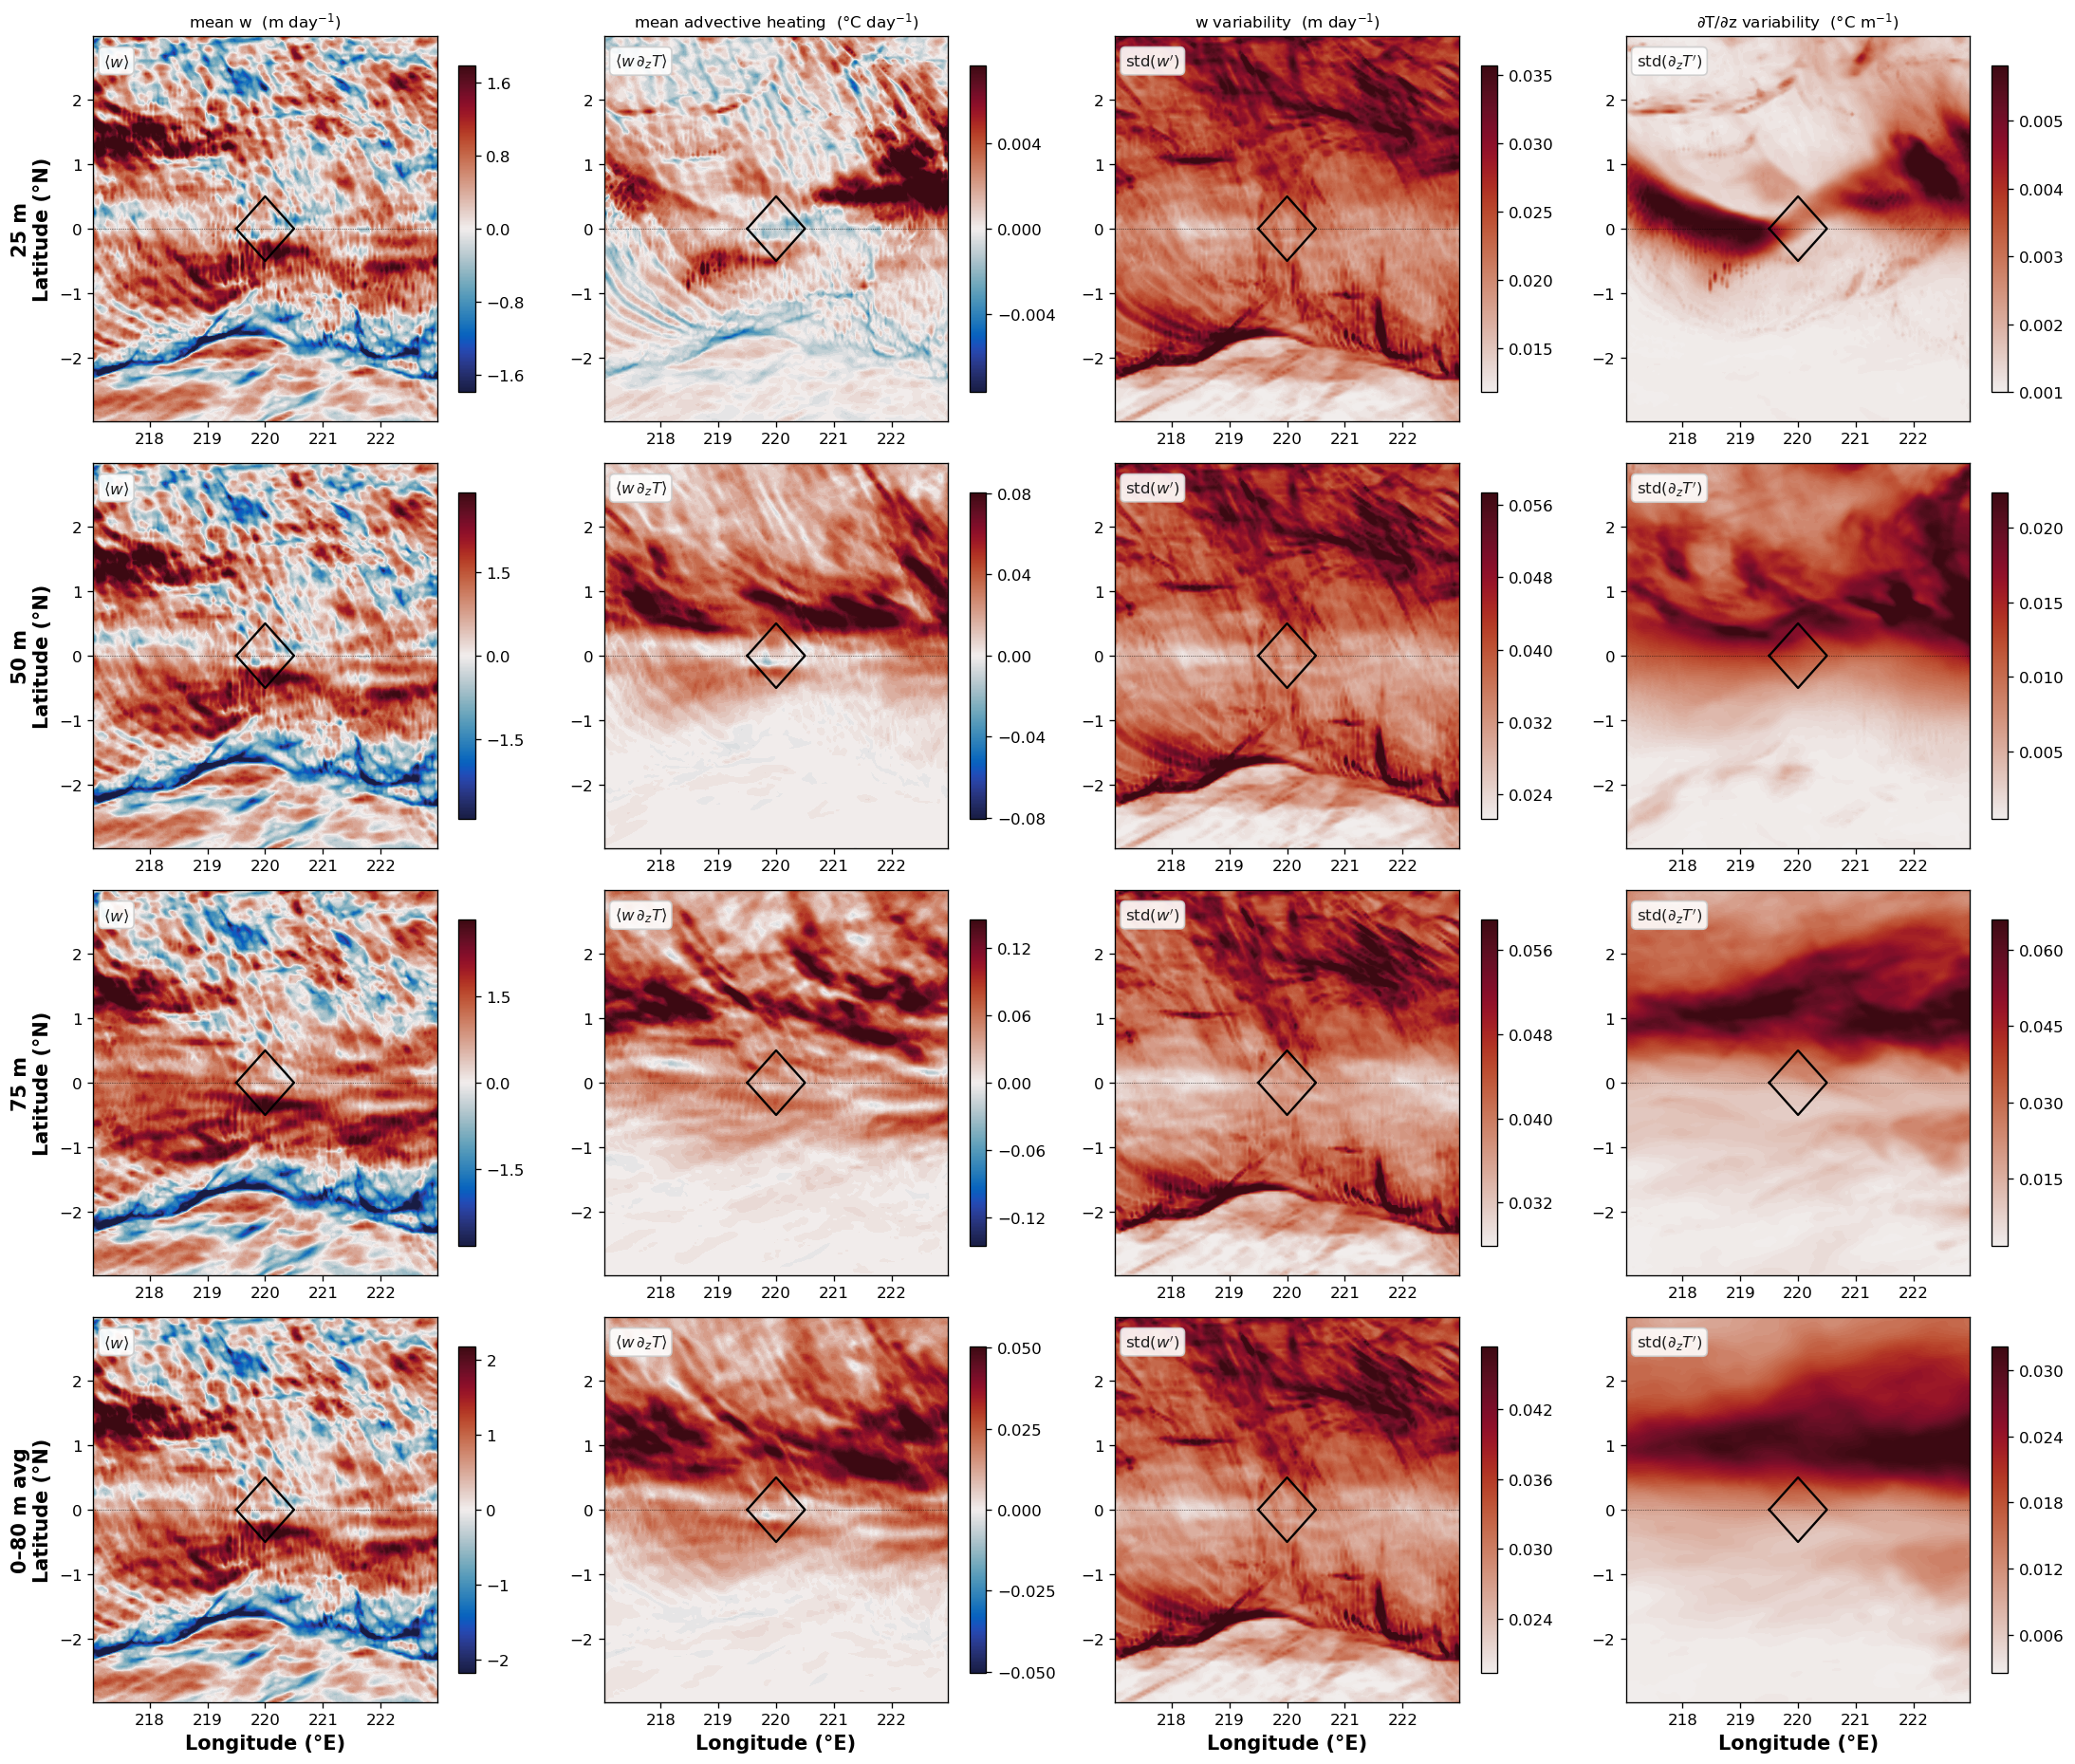

In [5]:
save(hft.make_context_maps(), "context_maps_reliability.png");